## Dataset Summary

[**Adventure Works 2022 dataset**](https://www.kaggle.com/datasets/algorismus/adventure-works-in-excel-tables?utm_source=chatgpt.com):

This dataset contains the sales records, targets, and master data for a B2B company. It tracks every sale made by specific salespeople to various resellers, including what products were sold, in what quantity, and for how much. The data also includes the monthly sales targets assigned to each employee, allowing for performance tracking. Additional dimensions cover product categories, regional territories, and reseller business types. Essentially, it provides a complete picture of the sales pipeline from the salesperson's target through to the final customer transaction.


**Data Components**:
1. Sales Transactions - Actual sales records with quantities and amounts
2. Employee Targets - Monthly sales goals for each salesperson
3. Sales Team - Employee information and territory assignments
4. Reseller Network - B2B customer details and business types
5. Product Catalog - Product categories, subcategories, and costs
6. Regional Structure - Geographical sales territories and countries


**» Sales Table**

Main Fact Table Records every sales transaction

| Column            | Type     | Description                               |
|-------------------|----------|-------------------------------------------|
| SalesOrderNumber  | String   | Unique identifier for each order         |
| OrderDate         | Date     | Date when sale occurred                  |
| EmployeeKey       | String   | Links to salesperson who made sale       |
| ResellerKey       | String   | Links to reseller business               |
| ProductKey        | String   | Links to product sold                    |
| SalesTerritoryKey | String   | Links to region where sale occurred      |
| Quantity          | Integer  | Number of units sold                     |
| Unit Price        | Numeric  | Price per unit                           |
| Cost              | Numeric  | Associated costs for the sale            |
| Sales             | Numeric  | Total sales amount (Quantity × Unit Price)|


**» Product Table**

Product catalog and categories


| Column                   | Type     | Description                               |
|--------------------------|----------|-------------------------------------------|
| ProductKey               | String   | Unique product identifier (Primary Key)   |
| Product                  | String   | Product name                             |
| Category                 | String   | Main product category                    |
| Subcategory              | String   | Product subcategory                      |
| Color                    | String   | Product color                            |
| Standard Cost            | Numeric  | Manufacturing cost per unit              |
| Background Color Format  | String   | Display formatting for reports           |
| Font Color Format        | String   | Display formatting for reports           |


**» SalesPerson Table**

Master list of sales team members

| Column       | Type     | Description                               |
|--------------|----------|-------------------------------------------|
| EmployeeKey  | String   | Unique identifier (Primary Key)           |
| EmployeeID   | String   | Alternative employee identifier           |
| Salesperson  | String   | Full name of sales representative         |
| Title        | String   | Job role/position                         |
| UPN          | String   | User Principal Name (email/username)      |


**» SalesPersonRegion Table**

Defines which regions each salesperson covers

| Column            | Type     | Description                               |
|-------------------|----------|-------------------------------------------|
| EmployeeKey       | String   | Links to Salesperson table               |
| SalesTerritoryKey | String   | Links to Region table                    |


**» Region Table**

Geographical territory definitions

| Column            | Type     | Description                               |
|-------------------|----------|-------------------------------------------|
| SalesTerritoryKey | String   | Unique region identifier (Primary Key)    |
| Region            | String   | Territory name                           |
| Country           | String   | Country name                             |
| Group             | String   | Larger geographical grouping              |


**» Reseller Table**

Information about business customers

| Column          | Type     | Description                               |
|-----------------|----------|-------------------------------------------|
| ResellerKey     | String   | Unique identifier (Primary Key)           |
| Reseller        | String   | Business name                            |
| Business Type   | String   | Type of retail business                  |
| Country-Region  | String   | Country where reseller is located        |
| State-Province  | String   | State/Province location                  |
| City            | String   | City location                            |


**» Target Table**

Stores monthly sales targets for each employee

| Column       | Type     | Description                               |
|--------------|----------|-------------------------------------------|
| EmployeeID   | String   | Links to salesperson who has the target   |
| TargetMonth  | Date     | Month and year the target applies to      |
| Target       | Numeric  | Sales amount goal for that month          |




---



# Importing Libraries

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from scipy.stats import skew
from sklearn.preprocessing import LabelEncoder

# Load Dataset

In [157]:
sales = pd.read_excel('/content/Sales.xlsx')
salesperson = pd.read_excel('/content/Salesperson.xlsx')
salespersonRegion = pd.read_excel('/content/SalespersonRegion.xlsx')
targets = pd.read_excel('/content/Targets.xlsx')
region = pd.read_excel('/content/Region.xlsx')
product = pd.read_excel('/content/Product.xlsx')
reseller = pd.read_excel('/content/Reseller.xlsx')

# Sales Table

In [158]:
sales

,SalesOrderNumber,OrderDate,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,Quantity,Unit Price,Sales,Cost
0,SO43897,2017-08-25,235,312,282,4,2,28.84,57.68,63.45
1,SO43897,2017-08-25,351,312,282,4,2,2024.99,4049.98,3796.19
2,SO43897,2017-08-25,348,312,282,4,2,2024.99,4049.98,3796.19
3,SO43897,2017-08-25,232,312,282,4,2,28.84,57.68,63.45
4,SO44544,2017-11-18,292,312,282,4,2,818.70,1637.40,1413.62
...,...,...,...,...,...,...,...,...,...,...
57846,SO69476,2020-05-15,476,667,283,2,21,38.49,808.29,549.70
57847,SO69476,2020-05-15,474,667,283,2,19,38.49,731.31,497.35
57848,SO69493,2020-05-18,482,89,283,2,20,4.94,98.80,67.25
57849,SO69503,2020-05-20,482,79,282,3,23,4.94,113.62,77.33


In [159]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57851 entries, 0 to 57850
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   SalesOrderNumber   57851 non-null  object        
 1   OrderDate          57851 non-null  datetime64[ns]
 2   ProductKey         57851 non-null  int64         
 3   ResellerKey        57851 non-null  int64         
 4   EmployeeKey        57851 non-null  int64         
 5   SalesTerritoryKey  57851 non-null  int64         
 6   Quantity           57851 non-null  int64         
 7   Unit Price         57851 non-null  float64       
 8   Sales              57851 non-null  float64       
 9   Cost               57851 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(5), object(1)
memory usage: 4.4+ MB


In [160]:
sales.describe()

,OrderDate,ProductKey,ResellerKey,EmployeeKey,SalesTerritoryKey,Quantity,Unit Price,Sales,Cost
count,57851,57851.000000,57851.000000,57851.000000,57851.000000,57851.000000,57851.000000,57851.000000,57851.000000
mean,2019-04-16 05:42:08.046187520,408.636705,340.742978,286.131735,4.554424,3.528271,446.388513,1340.487981,1323.210932
min,2017-07-01 00:00:00,212.000000,1.000000,272.000000,1.000000,1.000000,1.330000,1.370000,0.860000
25%,2018-09-17 00:00:00,326.000000,166.000000,283.000000,3.000000,2.000000,34.930000,129.560000,97.150000
50%,2019-06-07 00:00:00,401.000000,327.000000,285.000000,4.000000,3.000000,214.240000,469.790000,461.440000
75%,2019-11-17 00:00:00,491.000000,514.000000,290.000000,6.000000,4.000000,672.290000,1516.160000,1510.300000
max,2020-05-31 00:00:00,606.000000,701.000000,296.000000,10.000000,44.000000,2146.960000,30993.040000,38530.390000
std,NaN,113.665645,205.493906,4.521832,2.412247,3.035766,521.880164,2151.753062,2169.787634


**Data types include**:

*   int64: 5 columns
*   float64: 3 columns
*   object (categorical/text): 1 columns
*   datetime64[ns]: 1 columns



In [161]:
sales.describe(include='object')

,SalesOrderNumber
count,57851
unique,3616
top,SO51721
freq,72


## Missing values

In [162]:
sales.isnull().sum()

,0
SalesOrderNumber,0
OrderDate,0
ProductKey,0
ResellerKey,0
EmployeeKey,0
SalesTerritoryKey,0
Quantity,0
Unit Price,0
Sales,0
Cost,0



**Missing values**: No missing values.

## Duplicated values

In [163]:
sales.duplicated().sum()

np.int64(0)

**There is no Duplicated values in the table**

##  Outliers and Skewness

In [164]:
numeric_features = sales.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = sales.select_dtypes(include='object').columns

In [165]:
#Count of outliers

outlier_counts = {}
for col in numeric_features:
        Q1 = sales[col].quantile(0.25)
        Q3 = sales[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        count = sales[(sales[col] < lower_bound) | (sales[col] > upper_bound)].shape[0]
        outlier_counts[col] = count
outlier_counts

{'ProductKey': 0,
 'ResellerKey': 0,
 'EmployeeKey': 747,
 'SalesTerritoryKey': 0,
 'Quantity': 4934,
 'Unit Price': 1852,
 'Sales': 6329,
 'Cost': 6090}

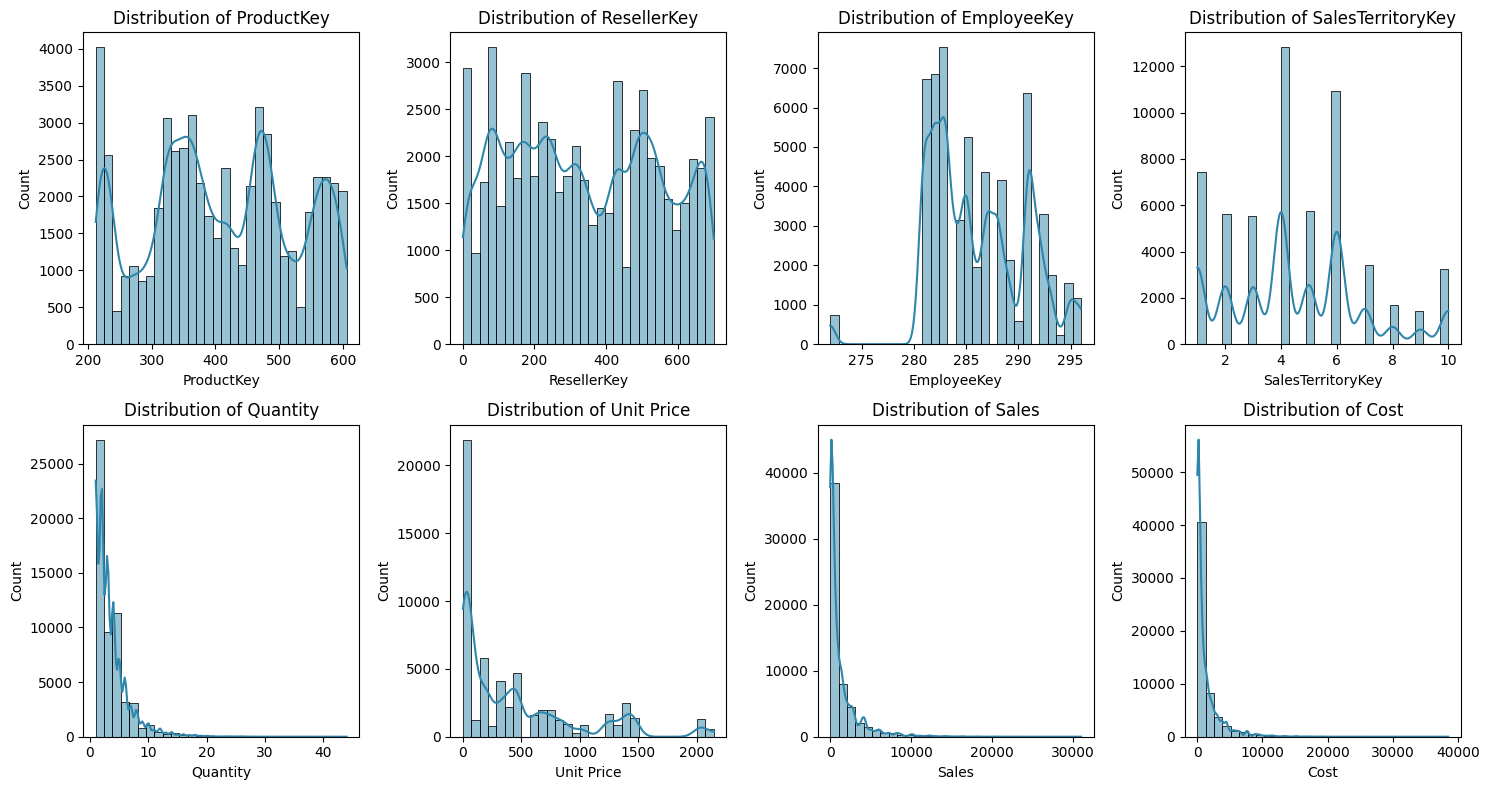

In [166]:
# HistPlot distributions for each feature

plt.figure(figsize=(15, 8))
for i, feature in enumerate(numeric_features):
    plt.subplot(2, 4, i+1)
    sns.histplot(sales[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

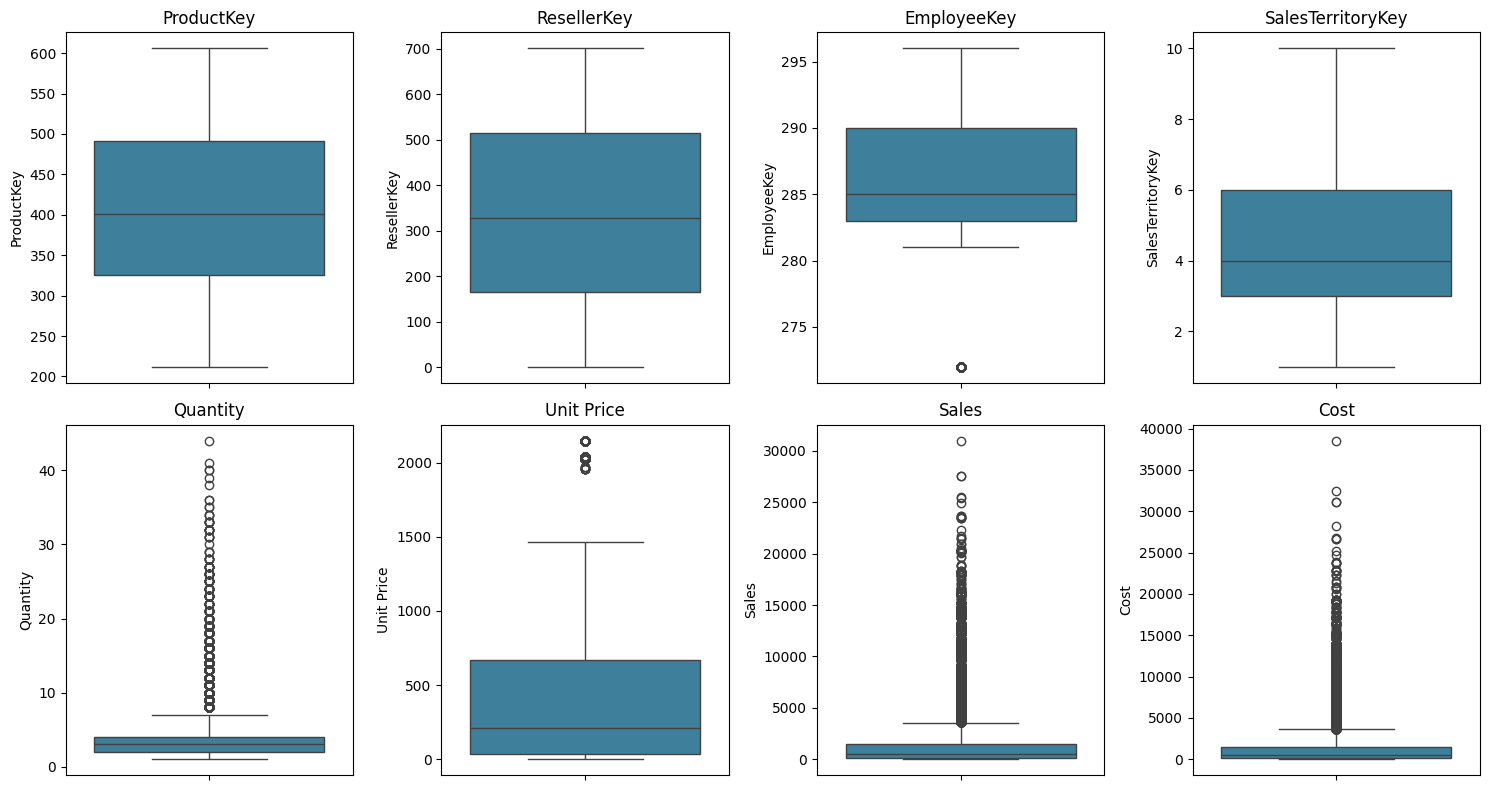

In [167]:
# BoxPlot distributions for each feature

plt.figure(figsize=(15, 8))
for i, feature in enumerate(numeric_features):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=sales[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

In [168]:
# Measure Skewness: Calculate how asymmetric the data is

for feature in numeric_features:
    if feature in sales.columns:
        skewness = skew(sales[feature].dropna())
        print(f"{feature}: {skewness:.2f}")

ProductKey: -0.01
ResellerKey: 0.08
EmployeeKey: 0.12
SalesTerritoryKey: 0.43
Quantity: 2.84
Unit Price: 1.41
Sales: 3.40
Cost: 3.56


In [169]:
# Get High Skew Features: Find columns with extreme asymmetry

high_skew_features = []
for feature in numeric_features:
    if feature in sales.columns:
        skewness = skew(sales[feature].dropna())
        if abs(skewness) > 1:
            high_skew_features.append((feature, skewness))

high_skew_features

[('Quantity', np.float64(2.8353826109682645)),
 ('Unit Price', np.float64(1.4130335675216503)),
 ('Sales', np.float64(3.4037361088207083)),
 ('Cost', np.float64(3.5559151567563263))]

In [97]:
# Apply Log Transformation: Use alogarithm to fix skewed data

# for feature, skew_val in high_skew_features:
#     if sales[feature].min() > 0:
#         sales[f'{feature}_log'] = np.log1p(sales[feature])
#         new_skew = skew(sales[f'{feature}_log'].dropna())

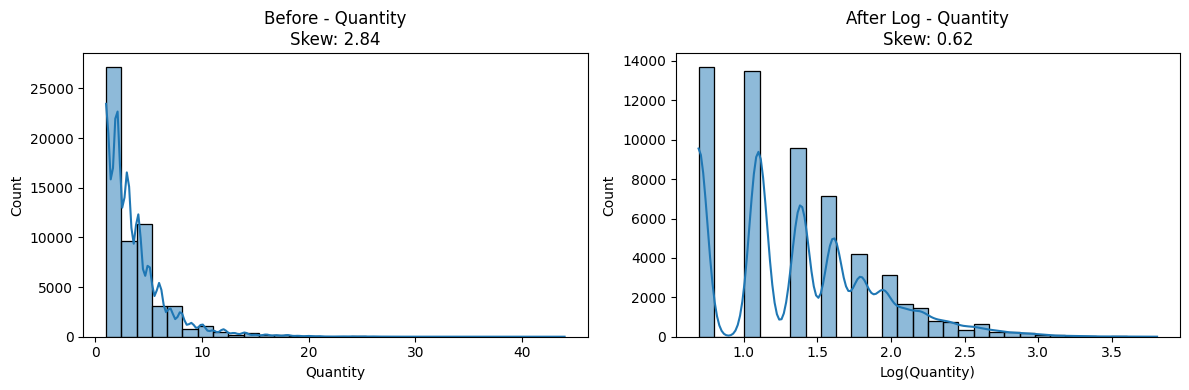

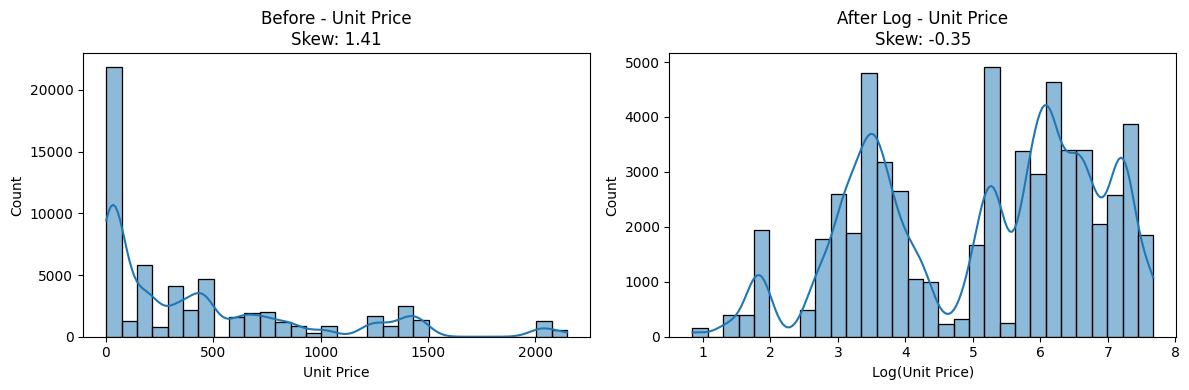

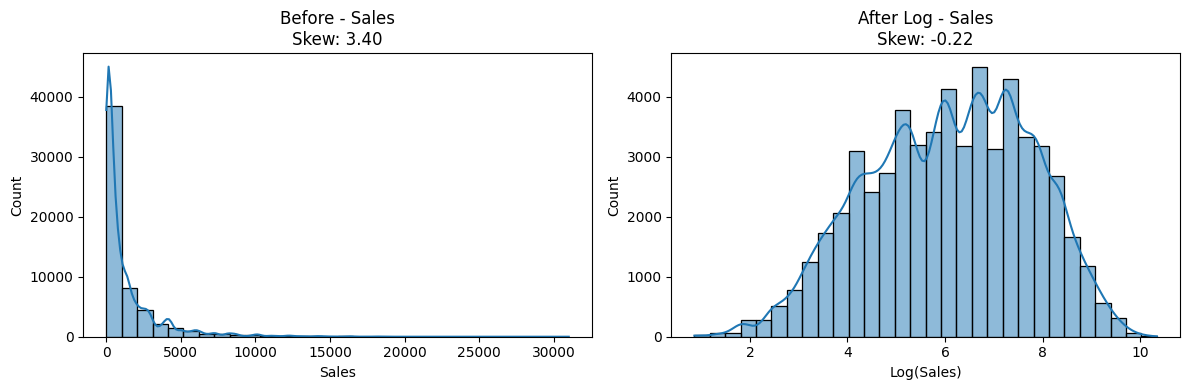

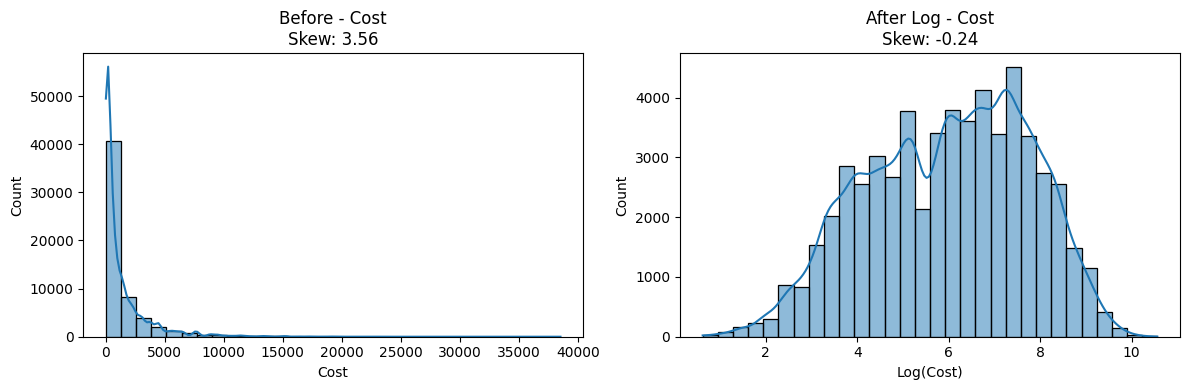

In [103]:
# Visualize Results: Show before/after distribution changes

for feature, skew_val in high_skew_features:
    plt.figure(figsize=(12, 4))

    # Before transformation
    plt.subplot(1, 2, 1)
    sns.histplot(sales[feature], kde=True, bins=30)
    plt.title(f'Before - {feature}\nSkew: {skew_val:.2f}')
    plt.xlabel(feature)

    # After transformation
    plt.subplot(1, 2, 2)
    transformed_data = np.log1p(sales[feature])
    sns.histplot(transformed_data, kde=True, bins=30)
    new_skew = skew(transformed_data.dropna())
    plt.title(f'After Log - {feature}\nSkew: {new_skew:.2f}')
    plt.xlabel(f'Log({feature})')

    plt.tight_layout()
    plt.show()

**Skewness Analysis & Transformation:**

*   Measured skewness in all numerical features
*   Identified highly skewed columns needing transformation
*   Reduced skewness towards normal distribution
*   Visualized improvements with comparison plots
*   Prepared clean data for further analysis


# Product Table

In [170]:
product

,ProductKey,Product,Standard Cost,Color,Subcategory,Category,Background Color Format,Font Color Format
0,210,"HL Road Frame - Black, 58",868.63,Black,Road Frames,Components,#000000,#FFFFFF
1,215,"Sport-100 Helmet, Black",12.03,Black,Helmets,Accessories,#000000,#FFFFFF
2,216,"Sport-100 Helmet, Black",13.88,Black,Helmets,Accessories,#000000,#FFFFFF
3,217,"Sport-100 Helmet, Black",13.09,Black,Helmets,Accessories,#000000,#FFFFFF
4,253,"LL Road Frame - Black, 58",176.20,Black,Road Frames,Components,#000000,#FFFFFF
...,...,...,...,...,...,...,...,...
392,594,"Mountain-500 Silver, 48",308.22,Silver,Mountain Bikes,Bikes,#C0C0C0,#000000
393,595,"Mountain-500 Silver, 52",308.22,Silver,Mountain Bikes,Bikes,#C0C0C0,#000000
394,601,LL Bottom Bracket,23.97,NaN,Bottom Brackets,Components,#DCDCDC,#000000
395,602,ML Bottom Bracket,44.95,NaN,Bottom Brackets,Components,#DCDCDC,#000000


In [171]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ProductKey               397 non-null    int64  
 1   Product                  397 non-null    object 
 2   Standard Cost            397 non-null    float64
 3   Color                    341 non-null    object 
 4   Subcategory              397 non-null    object 
 5   Category                 397 non-null    object 
 6   Background Color Format  397 non-null    object 
 7   Font Color Format        397 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 24.9+ KB


In [172]:
product.describe()

,ProductKey,Standard Cost
count,397.000000,397.000000
mean,408.000000,436.823073
std,114.748275,497.343079
min,210.000000,0.860000
25%,309.000000,37.120000
50%,408.000000,204.630000
75%,507.000000,660.910000
max,606.000000,2171.290000


**Data types include**:

*   int64: 1 columns
*   float64: 1 columns
*   object (categorical/text): 6 columns


In [173]:
product.describe(include='object')

,Product,Color,Subcategory,Category,Background Color Format,Font Color Format
count,397,341,397,397,397,397
unique,295,9,37,4,10,2
top,"LL Road Frame - Black, 44",Black,Road Frames,Components,#000000,#FFFFFF
freq,3,129,70,189,129,228


## Missing values

In [174]:
product.isnull().sum()

,0
ProductKey,0
Product,0
Standard Cost,0
Color,56
Subcategory,0
Category,0
Background Color Format,0
Font Color Format,0



**Missing values**: No missing values.

## Dupliacted values

In [175]:
product.duplicated().sum()

np.int64(0)

**There is no Duplicated values in the table**

In [176]:
numeric_features = product.select_dtypes(include=['int64', 'float64']).columns
categorical_features = product.select_dtypes(include='object').columns

In [177]:
#Count of outliers

outlier_counts = {}
for col in numeric_features:
        Q1 = product[col].quantile(0.25)
        Q3 = product[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        count = product[(product[col] < lower_bound) | (product[col] > upper_bound)].shape[0]
        outlier_counts[col] = count
outlier_counts

{'ProductKey': 0, 'Standard Cost': 13}

## Encoding

In [111]:
# Label Encoding for Category and Subcategory

# label_encoder = LabelEncoder()

# for col in ['Category', 'Subcategory']:
#     product[col] = label_encoder.fit_transform(product[col])

# Region Table

In [178]:
region

,SalesTerritoryKey,Region,Country,Group
0,1,Northwest,United States,North America
1,2,Northeast,United States,North America
2,3,Central,United States,North America
3,4,Southwest,United States,North America
4,5,Southeast,United States,North America
5,6,Canada,Canada,North America
6,7,France,France,Europe
7,8,Germany,Germany,Europe
8,9,Australia,Australia,Pacific
9,10,United Kingdom,United Kingdom,Europe


In [179]:
region.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   SalesTerritoryKey  10 non-null     int64 
 1   Region             10 non-null     object
 2   Country            10 non-null     object
 3   Group              10 non-null     object
dtypes: int64(1), object(3)
memory usage: 452.0+ bytes


In [180]:
region.describe()

,SalesTerritoryKey
count,10.00000
mean,5.50000
std,3.02765
min,1.00000
25%,3.25000
50%,5.50000
75%,7.75000
max,10.00000


**Data types include**:

*   int64: 1 columns
*   object (categorical/text): 3 columns



In [181]:
region.describe(include='object')

,Region,Country,Group
count,10,10,10
unique,10,6,3
top,Northwest,United States,North America
freq,1,5,6


## Missing values

In [182]:
region.isnull().sum()

,0
SalesTerritoryKey,0
Region,0
Country,0
Group,0



**Missing values**: No missing values.

## Duplicated values

In [183]:
region.duplicated().sum()

np.int64(0)

**There is no Duplicated values in the table**

In [184]:
numeric_features = region.select_dtypes(include=['int64', 'float64']).columns
categorical_features = region.select_dtypes(include='object').columns

In [185]:
#Count of outliers

outlier_counts = {}
for col in numeric_features:
        Q1 = region[col].quantile(0.25)
        Q3 = region[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        count = region[(region[col] < lower_bound) | (region[col] > upper_bound)].shape[0]
        outlier_counts[col] = count
outlier_counts

{'SalesTerritoryKey': 0}

**There is no outliers in the table**

## Encoding

In [186]:
# Label Encoding for Category and Subcategory

# label_encoder = LabelEncoder()

# for col in categorical_features:
#     region[col] = label_encoder.fit_transform(region[col])

# Reseller Table

In [187]:
reseller

,ResellerKey,Business Type,Reseller,City,State-Province,Country-Region
0,277,Specialty Bike Shop,The Bicycle Accessories Company,Alhambra,California,United States
1,455,Value Added Reseller,Timely Shipping Service,Alpine,California,United States
2,609,Value Added Reseller,Good Toys,Auburn,California,United States
3,492,Specialty Bike Shop,Basic Sports Equipment,Baldwin Park,California,United States
4,365,Specialty Bike Shop,Distinctive Store,Barstow,California,United States
...,...,...,...,...,...,...
696,340,Value Added Reseller,Nearby Cycle Shop,West Sussex,England,United Kingdom
697,106,Value Added Reseller,West Side Mart,Wokingham,England,United Kingdom
698,448,Warehouse,Action Bicycle Specialists,Woolston,England,United Kingdom
699,358,Value Added Reseller,Mail Market,York,England,United Kingdom


In [188]:
reseller.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ResellerKey     701 non-null    int64 
 1   Business Type   701 non-null    object
 2   Reseller        701 non-null    object
 3   City            701 non-null    object
 4   State-Province  701 non-null    object
 5   Country-Region  701 non-null    object
dtypes: int64(1), object(5)
memory usage: 33.0+ KB


In [189]:
reseller.describe()

,ResellerKey
count,701.000000
mean,351.000000
std,202.505555
min,1.000000
25%,176.000000
50%,351.000000
75%,526.000000
max,701.000000


**Data types include**:

*   int64: 1 columns
*   object (categorical/text): 5 columns



In [190]:
reseller.describe(include='object')

,Business Type,Reseller,City,State-Province,Country-Region
count,701,701,701,701,701
unique,3,699,451,65,6
top,Value Added Reseller,Friendly Bike Shop,Toronto,California,United States
freq,238,2,24,78,427


## Missing values

In [191]:
reseller.isnull().sum()

,0
ResellerKey,0
Business Type,0
Reseller,0
City,0
State-Province,0
Country-Region,0


**Missing values**: No missing values.

## Duplicated values

In [192]:
reseller.duplicated().sum()

np.int64(0)

**There is no Duplicated values in the table**

In [193]:
numeric_features = reseller.select_dtypes(include=['int64', 'float64']).columns
categorical_features = reseller.select_dtypes(include='object').columns

In [194]:
#Count of outliers

outlier_counts = {}
for col in numeric_features:
        Q1 = reseller[col].quantile(0.25)
        Q3 = reseller[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        count = reseller[(reseller[col] < lower_bound) | (reseller[col] > upper_bound)].shape[0]
        outlier_counts[col] = count
outlier_counts

{'ResellerKey': 0}

**Thers is no outliers in the table**

## Encoding

In [195]:
# Label Encoding for Category and Subcategory

# label_encoder = LabelEncoder()

# for col in categorical_features:
#     reseller[col] = label_encoder.fit_transform(reseller[col])

# SalesPerson Table

In [196]:
salesperson

,EmployeeKey,EmployeeID,Salesperson,Title,UPN
0,272,502097814,Stephen Jiang,North American Sales Manager,stephen-jiang@adventureworks.com
1,277,112432117,Brian Welcker,Director of Sales,brian-welcker@adventureworks.com
2,281,841560125,Michael Blythe,Sales Representative,michael-blythe@adventureworks.com
3,282,191644724,Linda Mitchell,Sales Representative,linda-mitchell@adventureworks.com
4,283,615389812,Jillian Carson,Sales Representative,jillian-carson@adventureworks.com
5,284,234474252,Garrett Vargas,Sales Representative,garrett-vargas@adventureworks.com
6,285,716374314,Tsvi Reiter,Sales Representative,tsvi-reiter@adventureworks.com
7,286,61161660,Pamela Ansman-Wolfe,Sales Representative,pamela-ansman-wolfe@adventureworks.com
8,287,139397894,Shu Ito,Sales Representative,shu-ito@adventureworks.com
9,288,399771412,José Saraiva,Sales Representative,jose-saraiva@adventureworks.com


In [197]:
salesperson.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   EmployeeKey  18 non-null     int64 
 1   EmployeeID   18 non-null     int64 
 2   Salesperson  18 non-null     object
 3   Title        18 non-null     object
 4   UPN          18 non-null     object
dtypes: int64(2), object(3)
memory usage: 852.0+ bytes


In [198]:
salesperson.describe()

,EmployeeKey,EmployeeID
count,18.000000,1.800000e+01
mean,286.944444,4.928963e+08
std,6.421217,3.341403e+08
min,272.000000,6.116166e+07
25%,283.250000,1.524596e+08
50%,287.500000,4.915714e+08
75%,291.750000,7.480411e+08
max,296.000000,9.875543e+08


**Data types include**:

*   int64: 2 columns
*   object (categorical/text): 3 columns

**Missing values**: No missing values.


In [199]:
salesperson.describe(include='object')

,Salesperson,Title,UPN
count,18,18,18
unique,18,5,18
top,Stephen Jiang,Sales Representative,stephen-jiang@adventureworks.com
freq,1,14,1


## Missing values

In [200]:
salesperson.isnull().sum()

,0
EmployeeKey,0
EmployeeID,0
Salesperson,0
Title,0
UPN,0


**Missing values**: No missing values.

## Duplicated values

In [201]:
salesperson.duplicated().sum()

np.int64(0)

**There is no Duplicated values in the table**

In [202]:
numeric_features = salesperson.select_dtypes(include=['int64', 'float64']).columns
categorical_features = salesperson.select_dtypes(include='object').columns

In [203]:
#Count of outliers

outlier_counts = {}
for col in numeric_features:
        Q1 = salesperson[col].quantile(0.25)
        Q3 = salesperson[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        count = salesperson[(salesperson[col] < lower_bound) | (salesperson[col] > upper_bound)].shape[0]
        outlier_counts[col] = count
outlier_counts

{'EmployeeKey': 0, 'EmployeeID': 0}

**There is no outliera in the table**

# SalesPersonRegion Table

In [204]:
salespersonRegion

,EmployeeKey,SalesTerritoryKey
0,272,1
1,272,2
2,272,3
3,272,4
4,272,5
5,272,6
6,277,1
7,277,2
8,277,3
9,277,4


In [205]:
salespersonRegion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeKey        39 non-null     int64
 1   SalesTerritoryKey  39 non-null     int64
dtypes: int64(2)
memory usage: 756.0 bytes


In [206]:
salespersonRegion.describe()

,EmployeeKey,SalesTerritoryKey
count,39.000000,39.000000
mean,282.538462,5.102564
std,7.401444,2.817192
min,272.000000,1.000000
25%,277.000000,3.000000
50%,282.000000,5.000000
75%,289.500000,7.000000
max,296.000000,10.000000


**Data types include**:

*   int64: 2 columns

**Missing values**: No missing values.


In [207]:
salespersonRegion.duplicated().sum()

np.int64(0)

## Missing values

In [208]:
salesperson.isnull().sum()

,0
EmployeeKey,0
EmployeeID,0
Salesperson,0
Title,0
UPN,0


## Duplicated values

In [209]:
salespersonRegion.duplicated().sum()

np.int64(0)

**There is no Duplicated values in the table**

In [210]:
numeric_features = salespersonRegion.select_dtypes(include=['int64', 'float64']).columns

In [211]:
#Count of outliers

outlier_counts = {}
for col in numeric_features:
        Q1 = salespersonRegion[col].quantile(0.25)
        Q3 = salespersonRegion[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        count = salespersonRegion[(salespersonRegion[col] < lower_bound) | (salespersonRegion[col] > upper_bound)].shape[0]
        outlier_counts[col] = count
outlier_counts

{'EmployeeKey': 0, 'SalesTerritoryKey': 0}

**There is no outliers**

# Targets Table

In [212]:
targets

,EmployeeID,Target,TargetMonth
0,90836195,500000,2017-12-01
1,112432117,500000,2017-07-01
2,139397894,500000,2017-12-01
3,191644724,500000,2017-09-01
4,502097814,500000,2017-07-01
...,...,...,...
804,954276278,75000,2021-02-01
805,954276278,100000,2021-03-01
806,954276278,125000,2021-04-01
807,954276278,150000,2021-05-01


In [213]:
targets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809 entries, 0 to 808
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   EmployeeID   809 non-null    int64         
 1   Target       809 non-null    int64         
 2   TargetMonth  809 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2)
memory usage: 19.1 KB


In [214]:
targets.describe()

,EmployeeID,Target,TargetMonth
count,8.090000e+02,8.090000e+02,809
mean,4.593992e+08,8.358591e+05,2019-10-07 11:28:51.025958144
min,6.116166e+07,1.000000e+04,2017-07-01 00:00:00
25%,1.393979e+08,2.250000e+05,2018-10-01 00:00:00
50%,4.810449e+08,5.000000e+05,2019-11-01 00:00:00
75%,7.163743e+08,8.000000e+05,2020-10-01 00:00:00
max,9.875543e+08,3.650000e+07,2021-12-01 00:00:00
std,3.212523e+08,2.189578e+06,NaN


**Data types include**:

*   int64: 2 columns
*   datetime64[ns]: 1 columns

**Missing values**: No missing values.


## Missing values

In [215]:
sales.isnull().sum()

,0
SalesOrderNumber,0
OrderDate,0
ProductKey,0
ResellerKey,0
EmployeeKey,0
SalesTerritoryKey,0
Quantity,0
Unit Price,0
Sales,0
Cost,0


## Duplicated values

In [216]:
targets.duplicated().sum()

np.int64(0)

**There is no Duplicated values in the table**

In [217]:
numeric_features = targets.select_dtypes(include=['int64', 'float64']).columns

In [218]:
#Count of outliers

outlier_counts = {}
for col in numeric_features:
        Q1 = targets[col].quantile(0.25)
        Q3 = targets[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        count = targets[(targets[col] < lower_bound) | (targets[col] > upper_bound)].shape[0]
        outlier_counts[col] = count
outlier_counts

{'EmployeeID': 0, 'Target': 87}

# Visualization

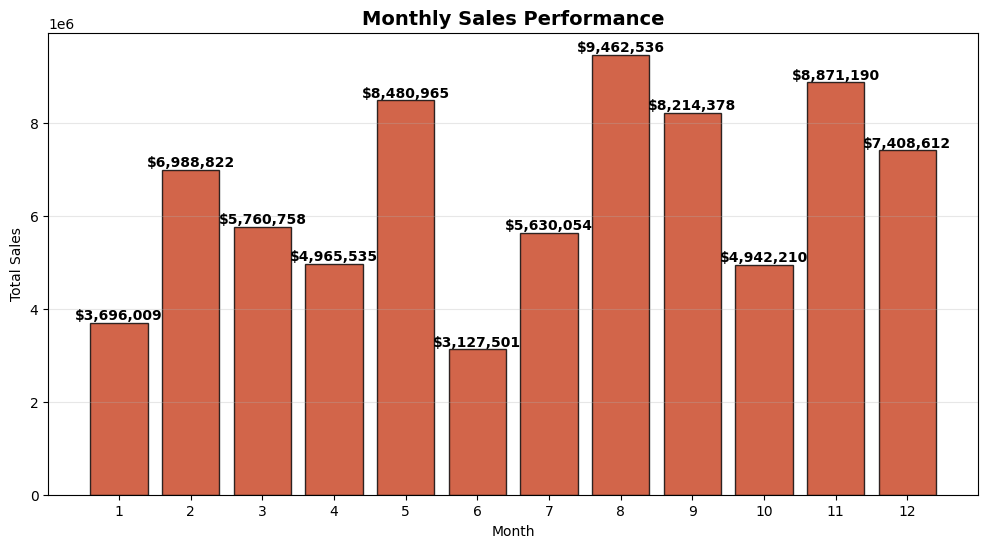

In [147]:
plt.figure(figsize=(12, 6))
monthly = sales.groupby(sales['OrderDate'].dt.month)['Sales'].sum()

plt.bar(monthly.index, monthly.values, color='#C73E1D', alpha=0.8, edgecolor='black')
plt.title('Monthly Sales Performance', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(monthly.values):
    plt.text(i+1, v + 1000, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.show()

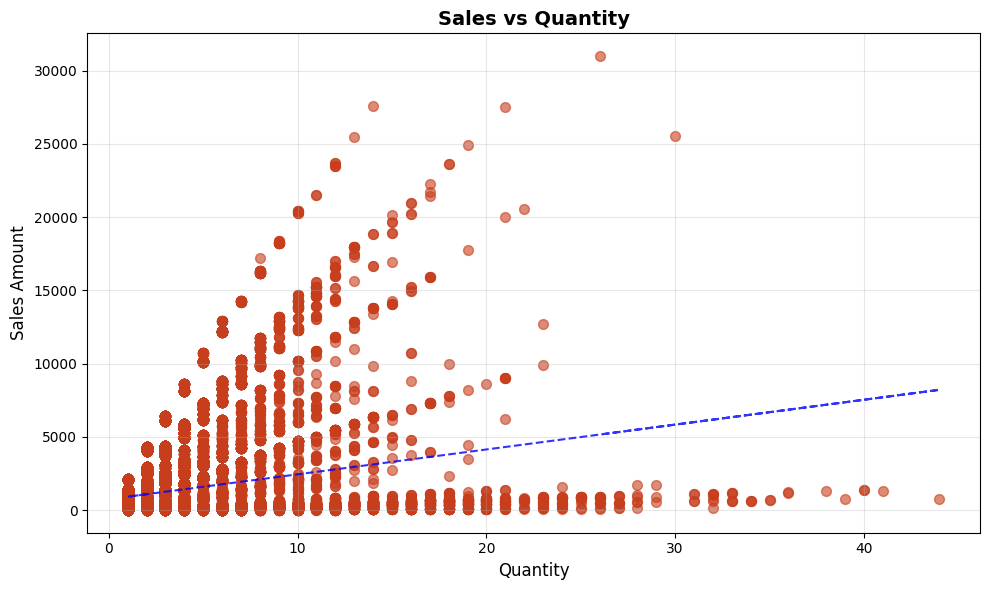

In [155]:
plt.figure(figsize=(10, 6))
plt.scatter(sales['Quantity'], sales['Sales'], alpha=0.6, color='#C73E1D', s=50)
plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Sales Amount', fontsize=12)
plt.title('Sales vs Quantity', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

z = np.polyfit(sales['Quantity'], sales['Sales'], 1)
p = np.poly1d(z)
plt.plot(sales['Quantity'], p(sales['Quantity']), "b--", alpha=0.8)

plt.tight_layout()
plt.show()

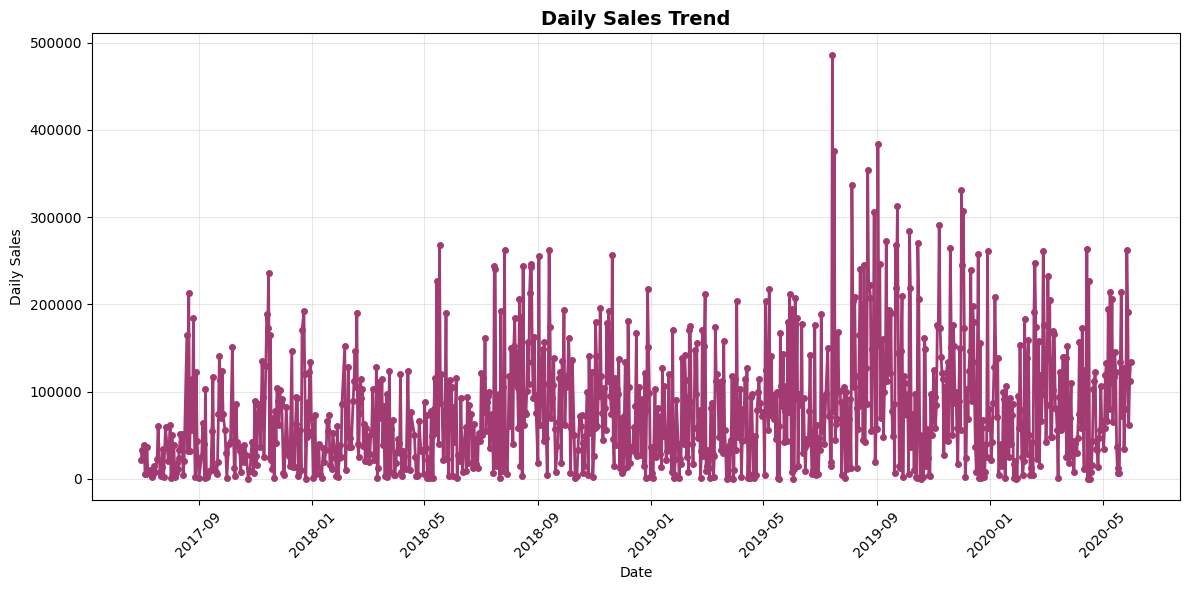

In [152]:
plt.figure(figsize=(12, 6))
daily_sales = sales.groupby('OrderDate')['Sales'].sum()

plt.plot(daily_sales.index, daily_sales.values, marker='o', linewidth=2,
         color='#A23B72', markersize=4)
plt.title('Daily Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

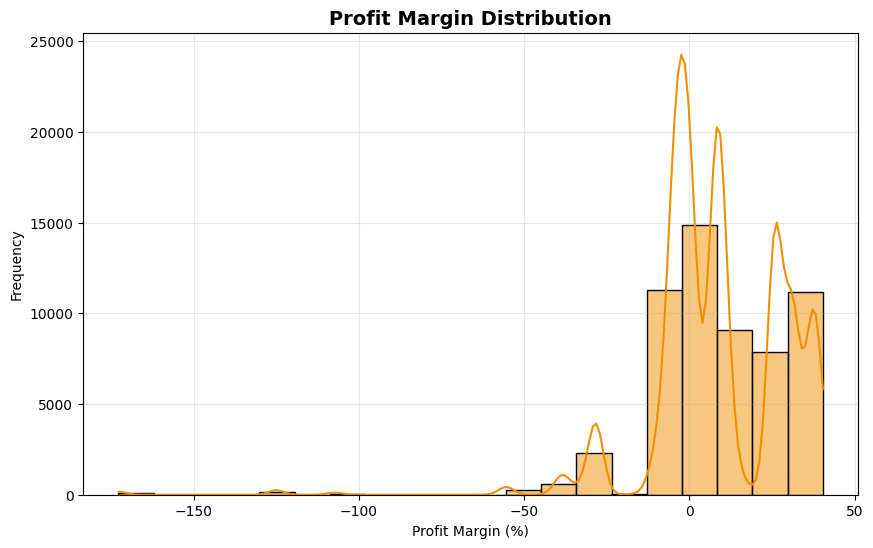

In [153]:
plt.figure(figsize=(10, 6))
profit_margin = ((sales['Sales'] - sales['Cost']) / sales['Sales']) * 100

sns.histplot(profit_margin, kde=True, color='#F18F01', bins=20)
plt.title('Profit Margin Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.show()

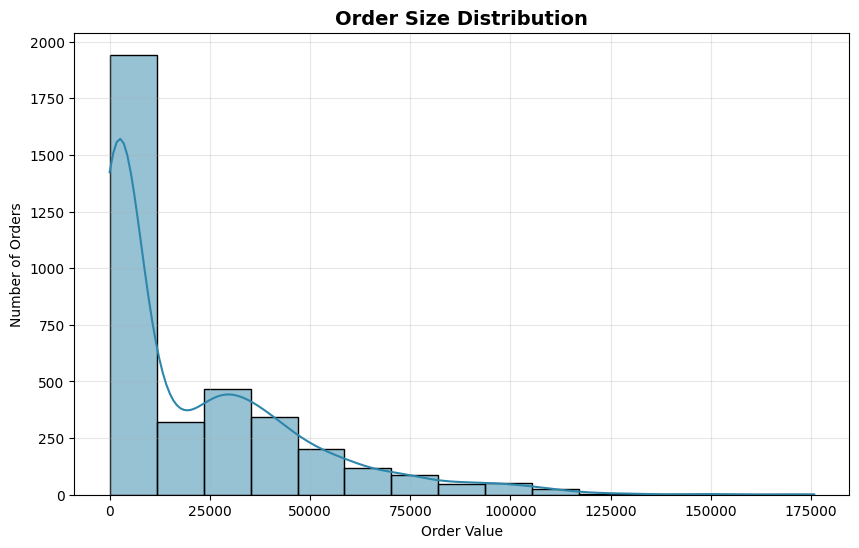

In [151]:
plt.figure(figsize=(10, 6))
order_sizes = sales.groupby('SalesOrderNumber')['Sales'].sum()

sns.histplot(order_sizes, kde=True, color='#2E86AB', bins=15)
plt.title('Order Size Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Order Value')
plt.ylabel('Number of Orders')
plt.grid(alpha=0.3)

plt.show()

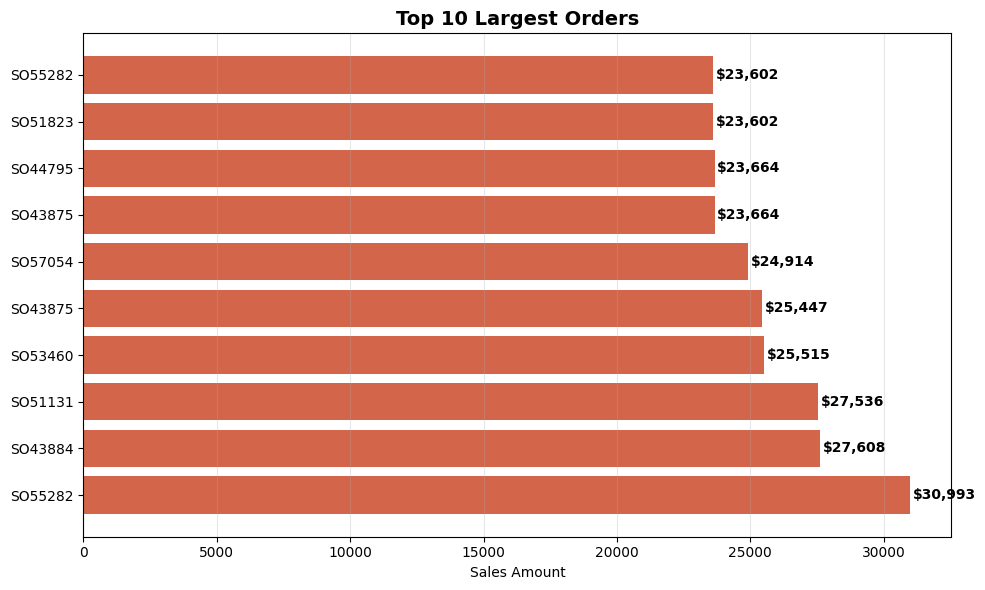

In [154]:
plt.figure(figsize=(10, 6))
top_orders = sales.nlargest(10, 'Sales')[['SalesOrderNumber', 'Sales']]

plt.barh(range(len(top_orders)), top_orders['Sales'], color='#C73E1D', alpha=0.8)
plt.yticks(range(len(top_orders)), top_orders['SalesOrderNumber'])
plt.xlabel('Sales Amount')
plt.title('Top 10 Largest Orders', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(top_orders['Sales']):
    plt.text(v + 100, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()